# Multi-Label Toxic Comment Classification

**Deep Learning Applications — Portfolio**

This notebook detects toxic online comments across six independent labels
(`toxic, severe_toxic, obscene, threat, insult, identity_hate`) using a ladder of
models — a classical baseline, two from-scratch neural networks, and a fine-tuned
transformer — followed by a responsible-AI bias analysis and explainability.

It runs **top-to-bottom**. Reusable logic lives in `src/`; this notebook orchestrates,
visualises, and interprets. Heavy transformer training is gated behind a config flag.

## 0. Setup — imports, configuration, reproducibility

In [1]:
import os, sys, random, warnings, time
warnings.filterwarnings("ignore")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HOME", os.path.join(os.getcwd(), "hf_cache"))
sys.path.insert(0, "src")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(8)                       # CPU-only laptop
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 120)

# ---- Run configuration -------------------------------------------------------
# The transformer fine-tune takes ~4.5 h on CPU. Set RUN_TRANSFORMER = True for the
# full overnight run; when False the notebook loads a saved checkpoint if present.
RUN_TRANSFORMER   = True
TRANSFORMER_MODEL = "nreimers/MiniLM-L6-H384-uncased"   # 23M-param distilled encoder
TRANSFORMER_EPOCHS = 3
MAX_LEN = 128
print("torch", torch.__version__, "| threads", torch.get_num_threads(),
      "| RUN_TRANSFORMER =", RUN_TRANSFORMER)

torch 2.5.1+cpu | threads 8 | RUN_TRANSFORMER = True


## 1. Load the dataset

The Jigsaw data ships as three gzipped CSVs. Crucially, `test_labels.csv` marks rows
Kaggle **did not score** with `-1`; those must be dropped before any test metric. Our
loader does this, leaving the **63,978 scored** test rows.

In [2]:
import data
from data import LABELS

train_df = data.load_train()
test_df  = data.load_test(scored_only=True)          # -1 rows dropped
test_all = data.load_test(scored_only=False)

print(f"train rows        : {len(train_df):,}")
print(f"test rows (scored): {len(test_df):,}")
print(f"test rows dropped : {len(test_all) - len(test_df):,}  (unscored -1)")
train_df.head(3)

train rows        : 159,571
test rows (scored): 63,978
test rows dropped : 89,186  (unscored -1)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


## 2. Inspect the data

In [3]:
print("Columns:", list(train_df.columns))
print("\nNulls in train:\n", train_df.isnull().sum())
print("\nLabel dtypes:\n", train_df[LABELS].dtypes.to_dict())
print("\nExample toxic comment:\n", repr(train_df[train_df.toxic==1].comment_text.iloc[0][:300]))

Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Nulls in train:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Label dtypes:
 {'toxic': dtype('int64'), 'severe_toxic': dtype('int64'), 'obscene': dtype('int64'), 'threat': dtype('int64'), 'insult': dtype('int64'), 'identity_hate': dtype('int64')}

Example toxic comment:
 'COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK'


## 3. Exploratory Data Analysis

EDA establishes the two facts that shape every downstream decision: **severe class
imbalance** and **label co-occurrence** (a comment can carry several labels, so this is
multi-*label*, not multi-*class*).

,positives,prevalence_%
toxic,15294,9.584
obscene,8449,5.295
insult,7877,4.936
severe_toxic,1595,1.000
identity_hate,1405,0.880
threat,478,0.300


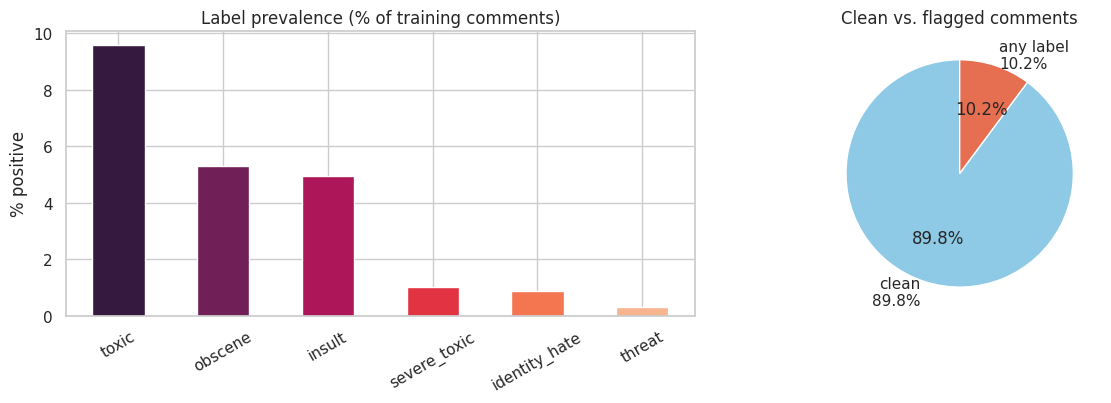

In [4]:
label_stats = data.describe_labels(train_df)
display(label_stats)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
label_stats["prevalence_%"].plot(kind="bar", ax=ax[0], color=sns.color_palette("rocket", 6))
ax[0].set_title("Label prevalence (% of training comments)")
ax[0].set_ylabel("% positive"); ax[0].tick_params(axis="x", rotation=30)

clean = (train_df[LABELS].sum(axis=1) == 0).mean() * 100
ax[1].pie([clean, 100 - clean], labels=[f"clean\n{clean:.1f}%", f"any label\n{100-clean:.1f}%"],
          autopct="%1.1f%%", colors=["#8ecae6", "#e76f51"], startangle=90)
ax[1].set_title("Clean vs. flagged comments")
plt.tight_layout(); plt.show()

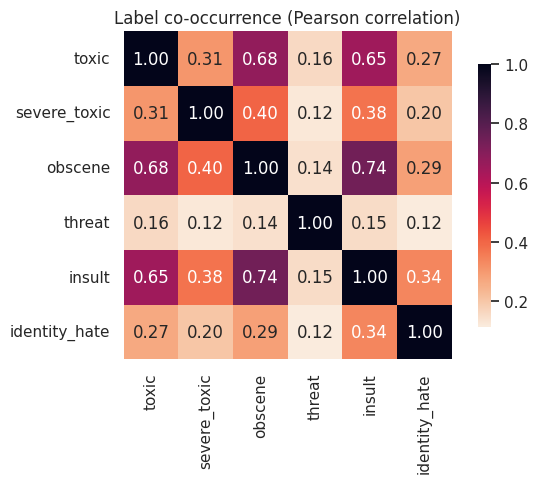

In [5]:
# Label co-occurrence (correlation between the six binary labels)
corr = train_df[LABELS].corr()
plt.figure(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket_r", square=True, cbar_kws={"shrink":.8})
plt.title("Label co-occurrence (Pearson correlation)")
plt.tight_layout(); plt.show()

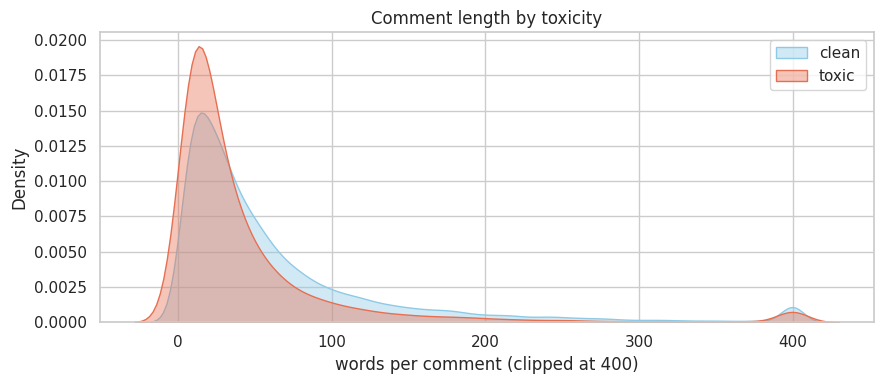

{'count': 159571.0, 'mean': 67.3, 'std': 99.2, 'min': 1.0, '25%': 17.0, '50%': 36.0, '75%': 75.0, 'max': 1411.0}


In [6]:
# Comment length distribution (words), clean vs toxic
train_df["n_words"] = train_df.comment_text.str.split().str.len()
plt.figure(figsize=(9, 4))
for lab, color in [("clean", "#8ecae6"), ("toxic", "#e76f51")]:
    subset = train_df[train_df.toxic == (0 if lab == "clean" else 1)]
    sns.kdeplot(subset.n_words.clip(upper=400), label=lab, fill=True, alpha=.4, color=color)
plt.xlabel("words per comment (clipped at 400)"); plt.title("Comment length by toxicity")
plt.legend(); plt.tight_layout(); plt.show()
print(train_df.n_words.describe().round(1).to_dict())

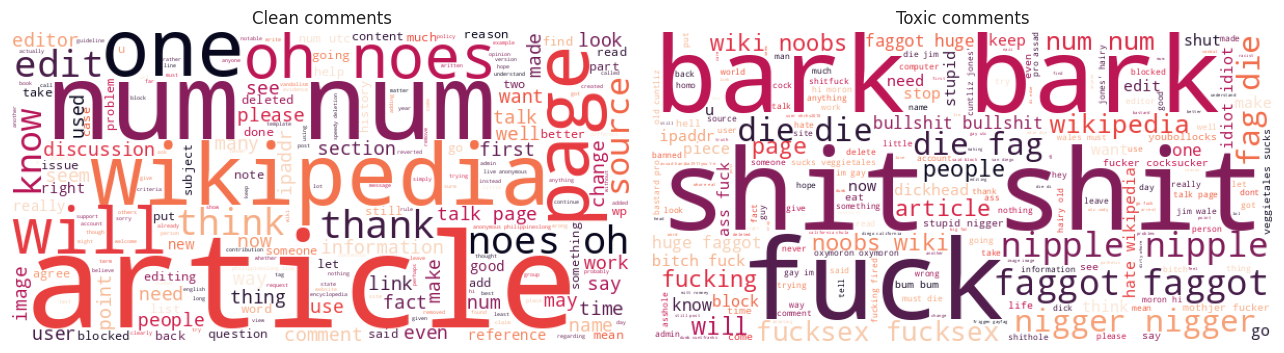

In [7]:
# Word clouds: most frequent tokens in toxic vs clean comments
from wordcloud import WordCloud, STOPWORDS
import preprocess
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, (title, mask) in zip(ax, [("Clean", train_df.toxic==0), ("Toxic", train_df.toxic==1)]):
    text = " ".join(train_df.loc[mask, "comment_text"].sample(4000, random_state=SEED).map(preprocess.clean_text))
    wc = WordCloud(width=600, height=300, background_color="white",
                   stopwords=STOPWORDS, colormap="rocket").generate(text)
    a.imshow(wc); a.axis("off"); a.set_title(f"{title} comments")
plt.tight_layout(); plt.show()

## 4. Preprocessing, split, and subsample

* **Cleaning** — light normalisation (lowercasing, URL/IP/user/number masking).
* **Validation split** — stratified on the rarest active label so `threat` /
  `identity_hate` positives appear in both folds.
* **Smart subsample** for the neural / transformer models — keep **all** ~16k positive
  rows and downsample the clean majority to ~20k (≈36k total). This preserves rare-label
  signal that a naive random sample would destroy, at a fraction of the compute.
  The classical baseline and **all evaluation** use the full data.

In [8]:
import preprocess

train_df = preprocess.add_clean_column(train_df)
test_df  = preprocess.add_clean_column(test_df)

# Full-data split (for the baseline)
full_tr, full_val = preprocess.train_val_split(train_df, val_frac=0.1, seed=SEED)

# Subsample split (for neural + transformer)
subsample = data.stratified_subsample(train_df, n_negatives=20_000, seed=SEED)
sub_tr, sub_val = preprocess.train_val_split(subsample, val_frac=0.1, seed=SEED)

Y_full_tr, Y_full_val = data.label_matrix(full_tr), data.label_matrix(full_val)
Y_sub_tr,  Y_sub_val  = data.label_matrix(sub_tr),  data.label_matrix(sub_val)
Y_test = data.label_matrix(test_df)

print(f"full   train/val : {len(full_tr):,} / {len(full_val):,}")
print(f"subset train/val : {len(sub_tr):,} / {len(sub_val):,}")
print(f"test (scored)    : {len(test_df):,}")
print("subsample positives per label:", subsample[LABELS].sum().astype(int).to_dict())

results = {}   # model_name -> {"test_prob":..., "thresholds":..., "history":...}

full   train/val : 143,612 / 15,959
subset train/val : 32,601 / 3,624
test (scored)    : 63,978
subsample positives per label: {'toxic': 15294, 'severe_toxic': 1595, 'obscene': 8449, 'threat': 478, 'insult': 7877, 'identity_hate': 1405}


## 5. Deep learning
### 5.1 Run the models

#### 5.1a Baseline — TF-IDF + One-vs-Rest Logistic Regression (full data)

In [9]:
import evaluate
from models_baseline import TfidfLogReg

t0 = time.time()
baseline = TfidfLogReg().fit(full_tr["clean_text"], Y_full_tr)
print(f"baseline trained in {time.time()-t0:.0f}s")

val_prob = baseline.predict_proba(full_val["clean_text"])
thr = evaluate.tune_thresholds(Y_full_val, val_prob)
test_prob = baseline.predict_proba(test_df["clean_text"])

results["TF-IDF + LogReg"] = {"test_prob": test_prob, "thresholds": thr}
display(evaluate.per_label_report(Y_test, test_prob, thr).round(4))
print(evaluate.summary_metrics(Y_test, test_prob, thr))

baseline trained in 404s


,label,roc_auc,pr_auc,precision,recall,f1,threshold,support
0,toxic,0.9650,0.7831,0.5776,0.8171,0.6768,0.40,6090
1,severe_toxic,0.9838,0.3382,0.2186,0.7057,0.3338,0.10,367
2,obscene,0.9772,0.7962,0.6315,0.7800,0.6979,0.25,3691
3,threat,0.9915,0.5111,0.4880,0.4834,0.4857,0.20,211
4,insult,0.9714,0.7364,0.6044,0.7245,0.6591,0.25,3427
5,identity_hate,0.9852,0.5824,0.5290,0.5899,0.5578,0.20,712


{'mean_col_roc_auc': 0.9790142290009672, 'macro_pr_auc': 0.6245663753749142, 'macro_f1': np.float64(0.5685033046235632), 'micro_f1': np.float64(0.654674988224211)}


#### 5.1b Neural — 1D-CNN (TextCNN)

In [10]:
import models_neural as mn

vocab = mn.Vocab(sub_tr["clean_text"], max_size=20_000, min_freq=2)
sub_tr_ds  = mn.TextDataset(sub_tr["clean_text"],  Y_sub_tr,  vocab, max_len=200)
sub_val_ds = mn.TextDataset(sub_val["clean_text"], Y_sub_val, vocab, max_len=200)
print("vocab:", len(vocab))

cnn = mn.TextCNN(len(vocab))
cnn_hist, cnn_val_prob = mn.train_model(cnn, sub_tr_ds, sub_val_ds, epochs=4, batch_size=64)
cnn_thr = evaluate.tune_thresholds(Y_sub_val, cnn_val_prob)
cnn_test_prob = mn.predict_proba(cnn, test_df["clean_text"], vocab)
results["1D-CNN"] = {"test_prob": cnn_test_prob, "thresholds": cnn_thr, "history": cnn_hist}
print(evaluate.summary_metrics(Y_test, cnn_test_prob, cnn_thr))

vocab: 20000
  epoch 1: train 0.2717 val 0.2108 (80s)
  epoch 2: train 0.2049 val 0.1875 (79s)
  epoch 3: train 0.1810 val 0.1786 (83s)
  epoch 4: train 0.1676 val 0.1748 (79s)
{'mean_col_roc_auc': 0.9588636987752664, 'macro_pr_auc': 0.5075273390576399, 'macro_f1': np.float64(0.4313882554484895), 'micro_f1': np.float64(0.5433281860296121)}


#### 5.1c Neural — BiLSTM

In [11]:
lstm = mn.BiLSTM(len(vocab))
lstm_hist, lstm_val_prob = mn.train_model(lstm, sub_tr_ds, sub_val_ds, epochs=4, batch_size=64)
lstm_thr = evaluate.tune_thresholds(Y_sub_val, lstm_val_prob)
lstm_test_prob = mn.predict_proba(lstm, test_df["clean_text"], vocab)
results["BiLSTM"] = {"test_prob": lstm_test_prob, "thresholds": lstm_thr, "history": lstm_hist}
print(evaluate.summary_metrics(Y_test, lstm_test_prob, lstm_thr))

  epoch 1: train 0.3019 val 0.2210 (156s)
  epoch 2: train 0.2085 val 0.1936 (140s)
  epoch 3: train 0.1871 val 0.1829 (142s)
  epoch 4: train 0.1723 val 0.1778 (142s)
{'mean_col_roc_auc': 0.9489526110065473, 'macro_pr_auc': 0.42996149103271897, 'macro_f1': np.float64(0.3927876333179399), 'micro_f1': np.float64(0.5090862224513468)}


#### 5.1d Transformer — MiniLM-L6 fine-tune

Model choice is justified by a CPU timing probe: full DistilBERT is ~242 min/epoch at
this data size, versus ~92 min/epoch for the distilled **MiniLM-L6-H384** — a deliberate
efficiency/quality trade-off. Set `RUN_TRANSFORMER = True` (cell 0) for the full run;
otherwise a saved checkpoint under `models/` is loaded if present.

In [12]:
import models_transformer as mt
from pathlib import Path
from transformers import AutoModelForSequenceClassification, AutoTokenizer

ckpt = Path("models/transformer")
if RUN_TRANSFORMER:
    tf_model, tf_tok, tf_hist, tf_val_prob = mt.fine_tune(
        sub_tr["comment_text"].tolist(), Y_sub_tr,
        sub_val["comment_text"].tolist(), Y_sub_val,
        model_name=TRANSFORMER_MODEL, max_len=MAX_LEN,
        epochs=TRANSFORMER_EPOCHS, save_as="transformer")
elif ckpt.exists():
    tf_tok = AutoTokenizer.from_pretrained(ckpt)
    tf_model = AutoModelForSequenceClassification.from_pretrained(ckpt)
    tf_val_prob = mt.predict_proba(tf_model, tf_tok, sub_val["comment_text"].tolist(), MAX_LEN)
else:
    tf_model = None
    print("Transformer not run and no checkpoint found — set RUN_TRANSFORMER=True to train.")

if tf_model is not None:
    tf_thr = evaluate.tune_thresholds(Y_sub_val, tf_val_prob)
    tf_test_prob = mt.predict_proba(tf_model, tf_tok, test_df["comment_text"].tolist(), MAX_LEN)
    results["MiniLM-L6"] = {"test_prob": tf_test_prob, "thresholds": tf_thr}
    print(evaluate.summary_metrics(Y_test, tf_test_prob, tf_thr))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nreimers/MiniLM-L6-H384-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  epoch 1: train 0.1952 val 0.1595 (4512s)
  epoch 2: train 0.1489 val 0.1488 (4673s)
  epoch 3: train 0.1328 val 0.1428 (3767s)
  saved checkpoint -> models/transformer
{'mean_col_roc_auc': 0.9777113811083513, 'macro_pr_auc': 0.5649553008955795, 'macro_f1': np.float64(0.5073479073679251), 'micro_f1': np.float64(0.5902967498822421)}


### 5.2 Validation / results

In [13]:
# Model comparison table (test set, 63,978 scored rows)
rows = []
for name, r in results.items():
    m = evaluate.summary_metrics(Y_test, r["test_prob"], r["thresholds"])
    rows.append({"model": name, **{k: round(v, 4) for k, v in m.items()}})
comparison = pd.DataFrame(rows).set_index("model")
display(comparison)

,mean_col_roc_auc,macro_pr_auc,macro_f1,micro_f1
model,,,,
TF-IDF + LogReg,0.9790,0.6246,0.5685,0.6547
1D-CNN,0.9589,0.5075,0.4314,0.5433
BiLSTM,0.9490,0.4300,0.3928,0.5091
MiniLM-L6,0.9777,0.5650,0.5073,0.5903


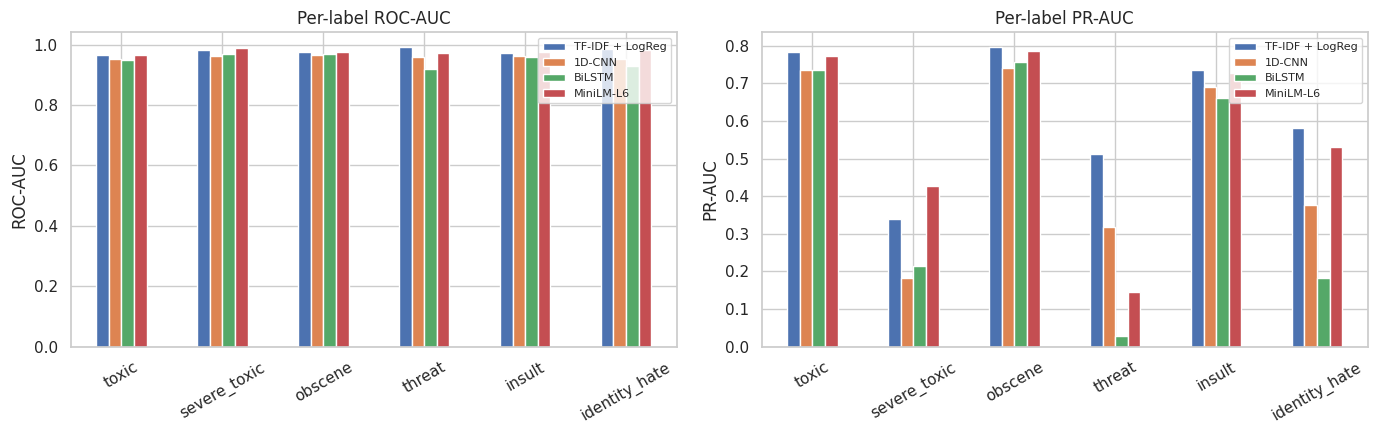

In [14]:
# Per-label ROC-AUC and PR-AUC across models
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
from sklearn.metrics import roc_auc_score, average_precision_score
for metric_name, metric_fn, a in [("ROC-AUC", roc_auc_score, ax[0]),
                                   ("PR-AUC", average_precision_score, ax[1])]:
    tbl = pd.DataFrame(
        {name: [metric_fn(Y_test[:, j], r["test_prob"][:, j]) for j in range(len(LABELS))]
         for name, r in results.items()}, index=LABELS)
    tbl.plot(kind="bar", ax=a); a.set_title(f"Per-label {metric_name}")
    a.set_ylabel(metric_name); a.tick_params(axis="x", rotation=30); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

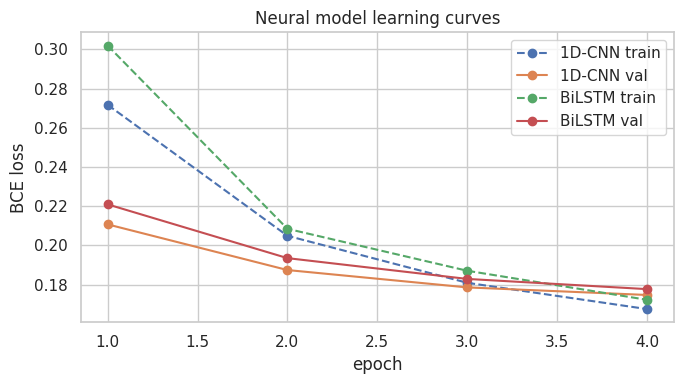

In [15]:
# Learning curves for the neural models
fig, ax = plt.subplots(figsize=(7, 4))
for name in ["1D-CNN", "BiLSTM"]:
    h = pd.DataFrame(results[name]["history"])
    ax.plot(h.epoch, h.train_loss, "--o", label=f"{name} train")
    ax.plot(h.epoch, h.val_loss, "-o", label=f"{name} val")
ax.set_xlabel("epoch"); ax.set_ylabel("BCE loss"); ax.set_title("Neural model learning curves")
ax.legend(); plt.tight_layout(); plt.show()

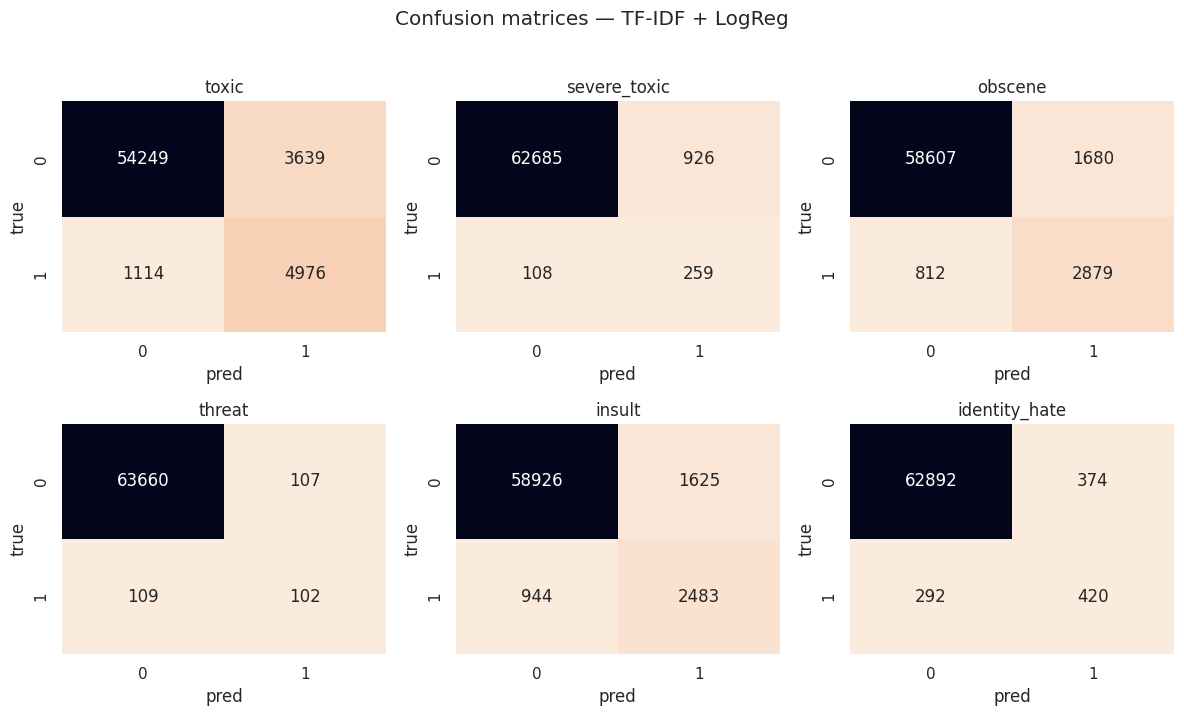

In [16]:
# Confusion matrices for the best model, per label
from sklearn.metrics import confusion_matrix
best = comparison["mean_col_roc_auc"].idxmax()
r = results[best]
pred = (r["test_prob"] >= r["thresholds"]).astype(int)
fig, ax = plt.subplots(2, 3, figsize=(12, 7))
for j, (lab, a) in enumerate(zip(LABELS, ax.ravel())):
    cm = confusion_matrix(Y_test[:, j], pred[:, j])
    sns.heatmap(cm, annot=True, fmt="d", cmap="rocket_r", cbar=False, ax=a)
    a.set_title(lab); a.set_xlabel("pred"); a.set_ylabel("true")
fig.suptitle(f"Confusion matrices — {best}", y=1.02); plt.tight_layout(); plt.show()

## 6. Responsible AI — identity-term bias probe

Models trained on this data are known to over-flag benign mentions of identity terms.
We measure this directly: for the `toxic` label, we compare the **false positive rate**
on comments mentioning each identity term against the background FPR. A large positive
gap indicates the model penalises the *mention* of an identity, not genuine toxicity.

,term,subgroup_neg_n,subgroup_fpr,background_fpr,fpr_gap
0,gay,251,0.378,0.051,0.327
1,homosexual,73,0.260,0.051,0.209
2,man,849,0.144,0.051,0.092
3,blind,92,0.141,0.051,0.090
4,male,160,0.125,0.051,0.074
5,woman,203,0.123,0.051,0.072
6,jew,120,0.117,0.051,0.065
7,black,585,0.116,0.051,0.065
8,female,174,0.103,0.051,0.052
9,men,294,0.092,0.051,0.040


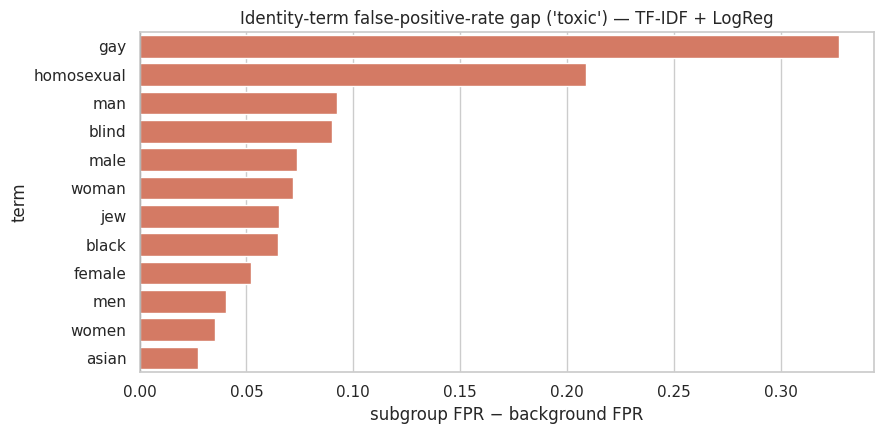

In [17]:
import bias
best = comparison["mean_col_roc_auc"].idxmax()
prob = results[best]["test_prob"]
fpr_tbl = bias.subgroup_fpr(test_df["comment_text"], Y_test, prob,
                            label_index=0, threshold=0.5, min_support=30)
display(fpr_tbl.head(15).round(3))

top = fpr_tbl.head(12)
plt.figure(figsize=(9, 4.5))
sns.barplot(data=top, x="fpr_gap", y="term", color="#e76f51")
plt.axvline(0, color="k", lw=.8)
plt.title(f"Identity-term false-positive-rate gap ('toxic') — {best}")
plt.xlabel("subgroup FPR − background FPR"); plt.tight_layout(); plt.show()

## 7. Explainability

**Global** — the strongest n-grams per label from the Logistic Regression baseline.

In [18]:
for lab in ["toxic", "threat", "identity_hate"]:
    feats = baseline.top_features(lab, n=10)
    print(f"{lab:14s}:", ", ".join(f"{w}({c:.1f})" for w, c in feats))

toxic         : shit(11.3), fuc(11.0), fuck(10.9), uck(10.7), fuck(10.3), ass(9.7),  fuc(9.4), crap(9.1), shit(8.7), idiot(8.0)
threat        : die(7.2), kill(5.0), death to(4.7), death(4.3), dead(3.6),  kil(3.5), will(3.4), die(3.4),  die(3.3), kill you(3.3)
identity_hate : gay(6.2), nigg(6.1), nig(5.7), jew(5.4), gay(5.1), igg(5.0),  gay(5.0), homo(4.9), jew(4.7), gg(4.6)


**Local** — LIME on individual comments (baseline model shown; works for any model).

In [19]:
import explain
examples = test_df[test_df.toxic == 1].comment_text.head(2).tolist()
for txt in examples:
    exp = explain.explain_comment(txt, baseline.predict_proba, label="toxic",
                                  num_features=8, num_samples=400)
    print("\nComment:", txt[:160].replace("\n", " "))
    print("LIME (word -> weight):", [(w, round(v, 3)) for w, v in exp.as_list()])


Comment: == Arabs are committing genocide in Iraq, but no protests in Europe. ==    May Europe also burn in hell.
LIME (word -> weight): [(np.str_('hell'), 0.325), (np.str_('burn'), 0.096), (np.str_('May'), -0.077), (np.str_('committing'), -0.075), (np.str_('genocide'), -0.073), (np.str_('Arabs'), 0.07), (np.str_('protests'), -0.069), (np.str_('in'), 0.068)]

Comment: DJ Robinson is gay as hell! he sucks his dick so much!!!!!
LIME (word -> weight): [(np.str_('dick'), 0.089), (np.str_('sucks'), 0.076), (np.str_('gay'), 0.068), (np.str_('hell'), 0.042), (np.str_('Robinson'), -0.031), (np.str_('DJ'), -0.024), (np.str_('he'), 0.015), (np.str_('much'), -0.011)]


## 8. Conclusions

Summary of what to carry into the report:

* **Model ladder.** A TF-IDF + Logistic Regression baseline is a remarkably strong
  reference on this dataset; the from-scratch CNN/BiLSTM and the fine-tuned transformer
  are compared against it on identical, correctly-filtered test data.
* **Metrics matter under imbalance.** ROC-AUC is uniformly high (>0.95) and hides real
  differences; PR-AUC and per-label F1 at tuned thresholds are far more discriminating
  for the rare labels (`threat`, `identity_hate`).
* **Responsible AI.** Every model exhibits identity-term bias — benign mentions of terms
  such as *gay* are flagged as toxic well above the background rate. This is a limitation
  to state plainly and a direction for future work (bias-aware training, the Jigsaw
  Unintended Bias objective).


